In [12]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["image.cmap"] = "gray"


In [13]:
val_size = 5000
mlp_train_limit = 30000
cnn_train_limit = 20000
test_eval_limit = 5000

epochs_mlp = 15
epochs_cnn = 6

batch_size_mlp = 128
batch_size_cnn = 64

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)

n_train = len(train_dataset)
perm = torch.randperm(n_train, generator=torch.Generator().manual_seed(seed)).tolist()

val_indices = perm[:val_size]
train_candidates = perm[val_size:]

mlp_perm = torch.randperm(len(train_candidates), generator=torch.Generator().manual_seed(seed + 1)).tolist()
cnn_perm = torch.randperm(len(train_candidates), generator=torch.Generator().manual_seed(seed + 2)).tolist()

mlp_train_size = min(mlp_train_limit, len(train_candidates))
cnn_train_size = min(cnn_train_limit, len(train_candidates))

mlp_train_indices = [train_candidates[i] for i in mlp_perm[:mlp_train_size]]
cnn_train_indices = [train_candidates[i] for i in cnn_perm[:cnn_train_size]]

n_test = len(test_dataset)
test_perm = torch.randperm(n_test, generator=torch.Generator().manual_seed(seed + 3)).tolist()
test_size = min(test_eval_limit, n_test)
test_indices = test_perm[:test_size]


In [14]:
val_subset = Subset(train_dataset, val_indices)
mlp_train_subset = Subset(train_dataset, mlp_train_indices)
cnn_train_subset = Subset(train_dataset, cnn_train_indices)
test_subset = Subset(test_dataset, test_indices)

val_loader = DataLoader(val_subset, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_subset, batch_size=256, shuffle=False, num_workers=0)

mlp_train_loader = DataLoader(mlp_train_subset, batch_size=batch_size_mlp, shuffle=True, num_workers=0)
cnn_train_loader = DataLoader(cnn_train_subset, batch_size=batch_size_cnn, shuffle=True, num_workers=0)


In [15]:
class MLPNet(nn.Module):
    def __init__(self, hidden_dims=(256, 128), activation="relu", dropout_p=0.0, num_classes=10):
        super().__init__()
        act_cls = nn.ReLU if activation == "relu" else nn.Sigmoid
        layers = []
        in_dim = 784
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(act_cls())
            if dropout_p > 0.0:
                layers.append(nn.Dropout(p=dropout_p))
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(nn.Flatten(), *layers)

    def forward(self, x):
        return self.net(x)


In [16]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

def train_one(model, train_loader, val_loader, epochs, lr, momentum, weight_decay, criterion):
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    history = {"train_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            total += y.size(0)
        train_loss = running_loss / total
        _, val_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch:02d}/{epochs} loss={train_loss:.4f} val_acc={val_acc:.4f}")
    return history


In [17]:
criterion = nn.CrossEntropyLoss()

lr_mlp = 0.01
momentum = 0.9
weight_decay_reg = 1e-4
dropout_p = 0.2

print("MLP: ReLU + regularization")
mlp_relu_reg = MLPNet(hidden_dims=(256, 128), activation="relu", dropout_p=dropout_p)
history_relu_reg = train_one(mlp_relu_reg, mlp_train_loader, val_loader, epochs_mlp, lr_mlp, momentum, weight_decay_reg, criterion)

print(f"Final val_acc (ReLU + reg) = {history_relu_reg['val_acc'][-1]:.4f}")

print("MLP: ReLU + NO regularization")
mlp_relu_noreg = MLPNet(hidden_dims=(256, 128), activation="relu", dropout_p=0.0)
history_relu_noreg = train_one(mlp_relu_noreg, mlp_train_loader, val_loader, epochs_mlp, lr_mlp, momentum, 0.0, criterion)

print(f"Final val_acc (ReLU + no reg) = {history_relu_noreg['val_acc'][-1]:.4f}")

print("MLP: Sigmoid + regularization")
mlp_sigmoid_reg = MLPNet(hidden_dims=(256, 128), activation="sigmoid", dropout_p=dropout_p)
history_sigmoid_reg = train_one(mlp_sigmoid_reg, mlp_train_loader, val_loader, epochs_mlp, lr_mlp, momentum, weight_decay_reg, criterion)

print(f"Final val_acc (sigmoid + reg) = {history_sigmoid_reg['val_acc'][-1]:.4f}")

def test_acc(model):
    _, acc = evaluate(model, test_loader, criterion)
    return acc

models = {
    "ReLU + reg": mlp_relu_reg,
    "ReLU + no reg": mlp_relu_noreg,
    "Sigmoid + reg": mlp_sigmoid_reg,
}

for name, model in models.items():
    acc = test_acc(model)
    print(f"{name}: test_acc={acc:.4f}")


MLP: ReLU + regularization
Epoch 01/15 loss=1.2295 val_acc=0.8646
Epoch 02/15 loss=0.4197 val_acc=0.8990
Epoch 03/15 loss=0.3257 val_acc=0.9142
Epoch 04/15 loss=0.2658 val_acc=0.9218
Epoch 05/15 loss=0.2296 val_acc=0.9362
Epoch 06/15 loss=0.2011 val_acc=0.9436
Epoch 07/15 loss=0.1779 val_acc=0.9492
Epoch 08/15 loss=0.1589 val_acc=0.9518
Epoch 09/15 loss=0.1449 val_acc=0.9566
Epoch 10/15 loss=0.1310 val_acc=0.9594
Epoch 11/15 loss=0.1233 val_acc=0.9602
Epoch 12/15 loss=0.1145 val_acc=0.9620
Epoch 13/15 loss=0.1038 val_acc=0.9658
Epoch 14/15 loss=0.0966 val_acc=0.9642
Epoch 15/15 loss=0.0923 val_acc=0.9684
Final val_acc (ReLU + reg) = 0.9684
MLP: ReLU + NO regularization
Epoch 01/15 loss=1.1565 val_acc=0.8654
Epoch 02/15 loss=0.3532 val_acc=0.8952
Epoch 03/15 loss=0.2865 val_acc=0.9064
Epoch 04/15 loss=0.2449 val_acc=0.9240
Epoch 05/15 loss=0.2097 val_acc=0.9308
Epoch 06/15 loss=0.1829 val_acc=0.9336
Epoch 07/15 loss=0.1597 val_acc=0.9438
Epoch 08/15 loss=0.1407 val_acc=0.9478
Epoch 09/1

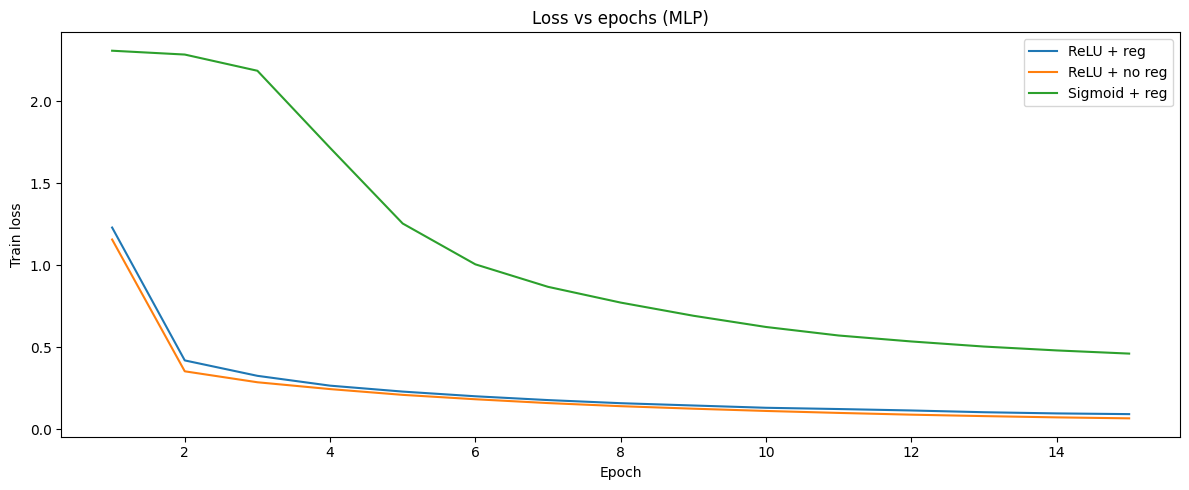

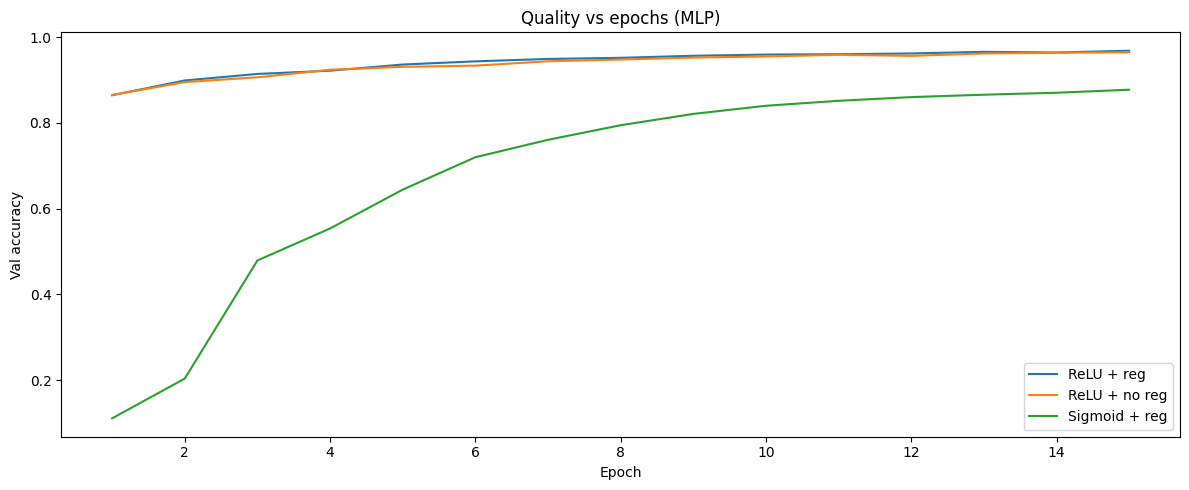

In [18]:
epochs_arr = np.arange(1, epochs_mlp + 1)

plt.figure()
plt.plot(epochs_arr, history_relu_reg["train_loss"], label="ReLU + reg")
plt.plot(epochs_arr, history_relu_noreg["train_loss"], label="ReLU + no reg")
plt.plot(epochs_arr, history_sigmoid_reg["train_loss"], label="Sigmoid + reg")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Loss vs epochs (MLP)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(epochs_arr, history_relu_reg["val_acc"], label="ReLU + reg")
plt.plot(epochs_arr, history_relu_noreg["val_acc"], label="ReLU + no reg")
plt.plot(epochs_arr, history_sigmoid_reg["val_acc"], label="Sigmoid + reg")
plt.xlabel("Epoch")
plt.ylabel("Val accuracy")
plt.title("Quality vs epochs (MLP)")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(16 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)


CNN: training
Epoch 01/6 loss=0.8595 val_acc=0.8720
Epoch 02/6 loss=0.2434 val_acc=0.9344
Epoch 03/6 loss=0.1588 val_acc=0.9560
Epoch 04/6 loss=0.1183 val_acc=0.9588
Epoch 05/6 loss=0.1010 val_acc=0.9632
Epoch 06/6 loss=0.0882 val_acc=0.9690
CNN: test_acc=0.9770


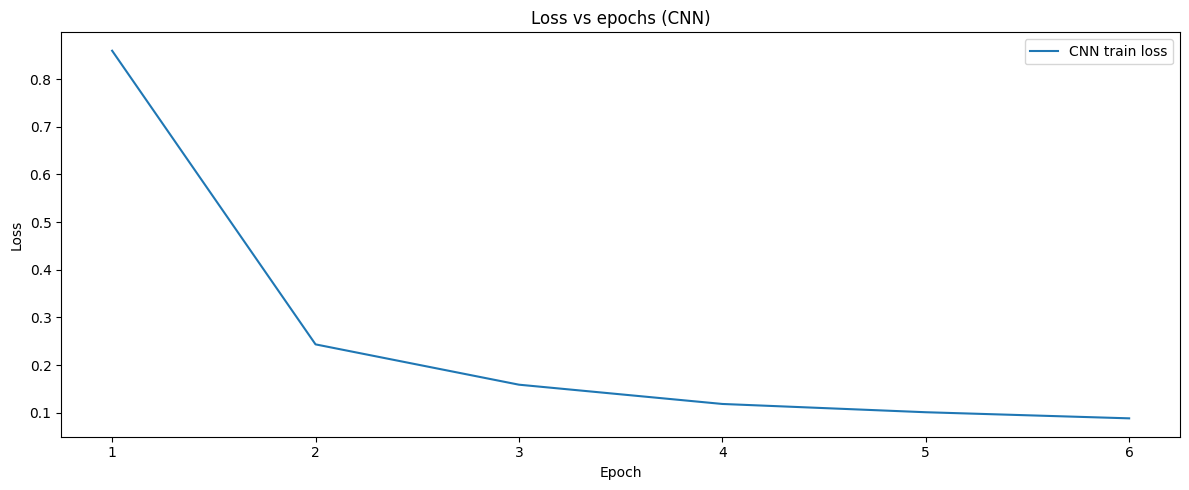

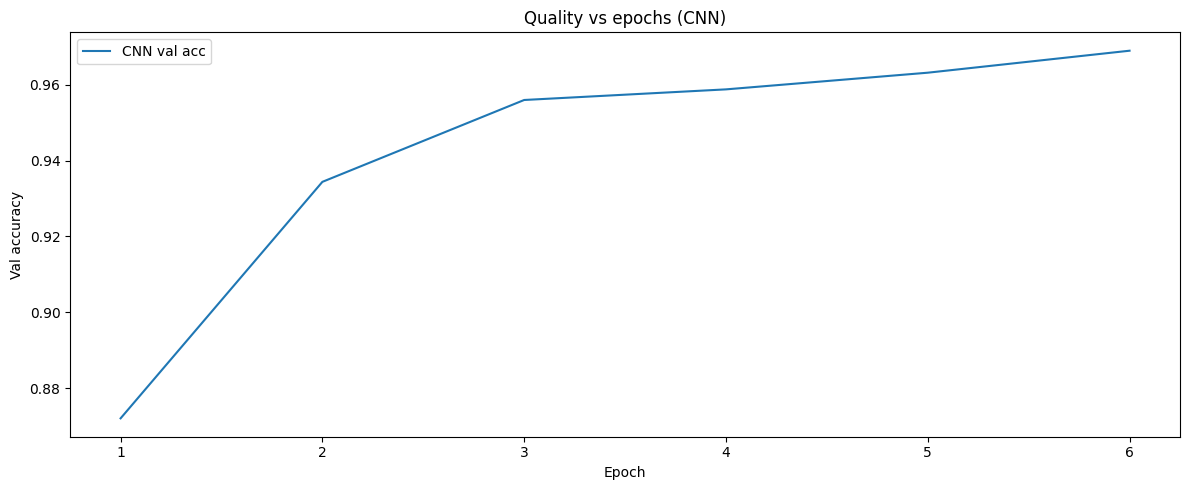

In [20]:
lr_cnn = 0.005

print("CNN: training")
cnn = SimpleCNN()
history_cnn = train_one(cnn, cnn_train_loader, val_loader, epochs_cnn, lr_cnn, momentum, 0.0, criterion)

cnn_loss, cnn_acc = evaluate(cnn, test_loader, criterion)
print(f"CNN: test_acc={cnn_acc:.4f}")

epochs_cnn_arr = np.arange(1, epochs_cnn + 1)

plt.figure()
plt.plot(epochs_cnn_arr, history_cnn["train_loss"], label="CNN train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs epochs (CNN)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(epochs_cnn_arr, history_cnn["val_acc"], label="CNN val acc")
plt.xlabel("Epoch")
plt.ylabel("Val accuracy")
plt.title("Quality vs epochs (CNN)")
plt.legend()
plt.tight_layout()
plt.show()


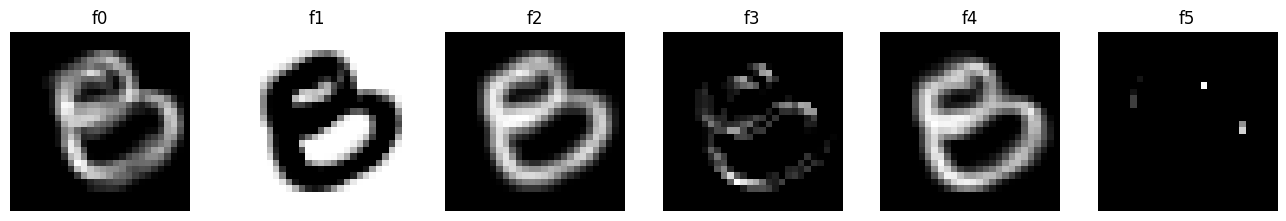

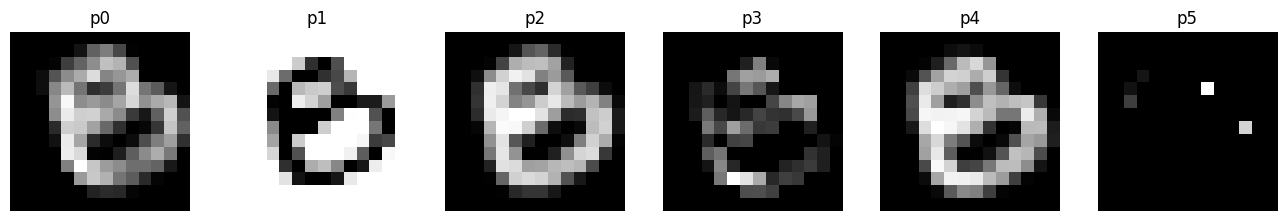

True label: 8


In [21]:
cnn.eval()
x0, y0 = test_subset[0]
with torch.no_grad():
    x0 = x0.unsqueeze(0).to(device)
    conv1_out = cnn.conv1(x0)
    relu1 = F.relu(conv1_out)
    pool1 = cnn.pool(relu1)

n_show = 6
plt.figure(figsize=(2.2 * n_show, 2.2))
for k in range(n_show):
    ax = plt.subplot(1, n_show, k + 1)
    ax.imshow(relu1[0, k].detach().cpu().numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(f"f{k}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(2.2 * n_show, 2.2))
for k in range(n_show):
    ax = plt.subplot(1, n_show, k + 1)
    ax.imshow(pool1[0, k].detach().cpu().numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(f"p{k}")
plt.tight_layout()
plt.show()

print(f"True label: {y0}")


## Закономерности

В первых свёрточных слоях модель обычно выделяет простые локальные признаки: границы, штрихи, наклоны и небольшие углы. После `maxpool` эти признаки становятся более “крупными” и устойчивыми к небольшим сдвигам, поэтому карты на следующем этапе выглядят менее шумными и более сглаженными.